In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [4]:
np.random.seed(42)
x1 = np.random.rand(100)
x2 = np.random.rand(100)

def polynomial(x1, x2):
    return 4*x1**2 + 5*x2**2 - 2*x1*x2 + 3*x1 - 6*x2

y = polynomial(x1, x2)

In [5]:
X_input = np.column_stack([x1, x2])
poly = PolynomialFeatures(degree=2)
X = poly.fit_transform(X_input)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
def gradient_descent(X, y, lr, n_iter):
    n, m = X.shape
    w = np.zeros(m)
    losses = []
    for i in range(n_iter):
        y_pred = X @ w
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)
        gradient = (2/n) * X.T @ (y_pred - y)
        w = w - lr * gradient
    return w, losses

In [7]:
w, losses = gradient_descent(X_scaled, y, lr=0.1, n_iter=10000)
print(f"Фінальна помилка: {losses[-1]:.6f}")
print(w)


Фінальна помилка: 0.740431
[ 0.          0.88799468 -1.74985208  1.18968382 -0.42289144  1.52082402]


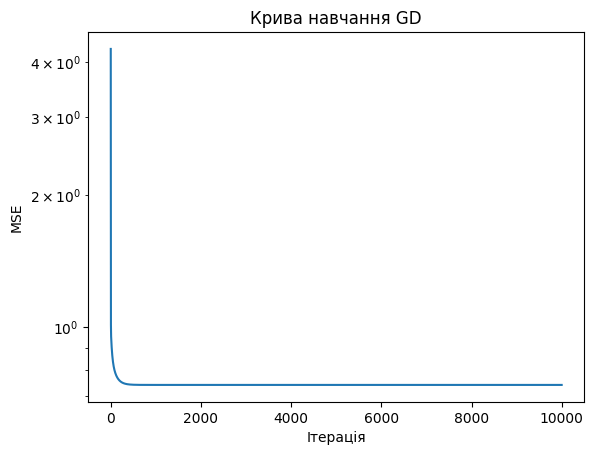

In [8]:
plt.plot(losses)
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Крива навчання GD')
plt.yscale('log')
plt.show()

 **висновки**

1. Необхідна нормалізація ОБОХ:
   - X → StandardScaler
   - y → (y - y.mean()) / y.std()
   
2. Без нормалізації y алгоритм збігається
   до помилки 0.74
   

In [9]:
y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

w, losses = gradient_descent(X_scaled, y_scaled, lr=0.1, n_iter=10000)
print(f"Фінальна помилка: {losses[-1]:.6f}")

Фінальна помилка: 0.000000


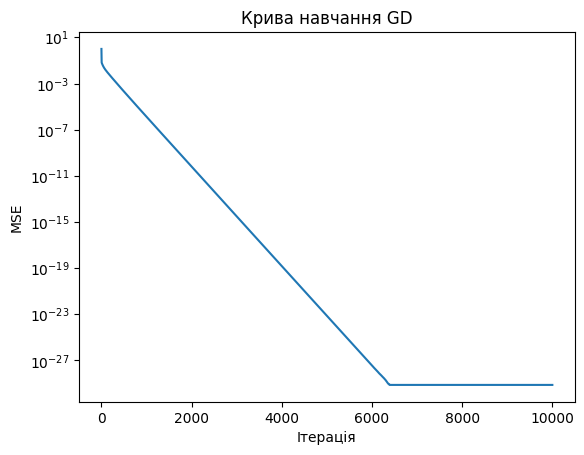

In [10]:
plt.plot(losses)
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Крива навчання GD')
plt.yscale('log')
plt.show()

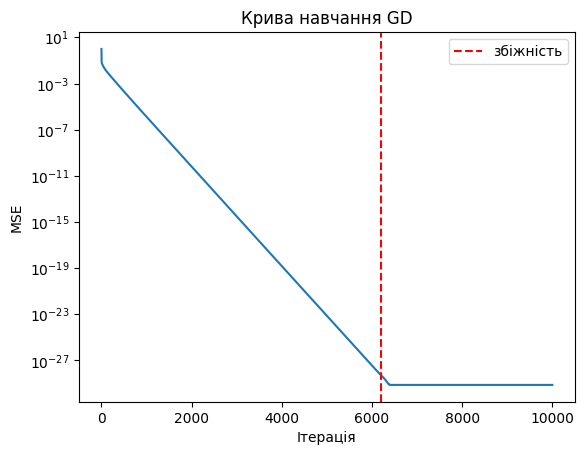

In [11]:
plt.plot(losses)
plt.axvline(x=6200, color='red', linestyle='--', label='збіжність')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Крива навчання GD')
plt.yscale('log')
plt.legend()
plt.show()

Оптимальна кількість ітерацій: 6100-6200 при lr=0.1

In [12]:
%timeit gradient_descent(X_scaled, y_scaled, lr=0.1, n_iter=6200)

90.4 ms ± 16.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


візуалізація(заради цікавості)

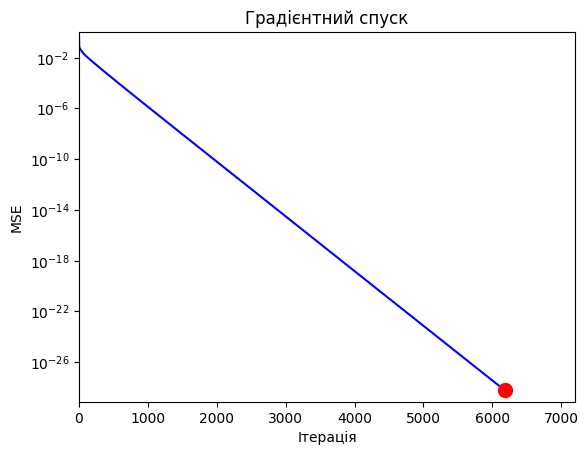

In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlim(0, 7200)
ax.set_ylim(min(losses), max(losses))
ax.set_yscale('log')
ax.set_xlabel('Ітерація')
ax.set_ylabel('MSE')
ax.set_title('Градієнтний спуск')

line, = ax.plot([], [], 'b-')
point, = ax.plot([], [], 'ro', markersize=10)  # черепашка 🐢

def update(frame):
    line.set_data(range(frame), losses[:frame])
    point.set_data([frame], [losses[frame]])
    return line, point

ani = FuncAnimation(fig, update, frames=list(range(0, 7000, 500)) + list(range(5000, 6200, 10)),
                    interval=50, blit=True)

HTML(ani.to_jshtml())

SGD

In [14]:
def gradient_descent_SGD(X, y, lr, n_iter):
    n, m = X.shape
    w = np.zeros(m)
    losses = []

    for i in range(n_iter):
        idx = np.random.randint(n)
        X_i = X[idx, :]
        y_i = y[idx]

        y_pred = X_i @ w
        loss = (y_i - y_pred) ** 2
        gradient = 2 * X_i * (y_pred - y_i)
        w = w - lr * gradient
        losses.append(loss)

    return w, losses

In [15]:
w_sgd, losses_sgd = gradient_descent_SGD(X_scaled, y_scaled, lr=0.1, n_iter=6200)
print(w_sgd)
print(f"Фінальна помилка: {losses_sgd[-1]:.6f}")

[ 0.          0.47158627 -0.92929184  0.63180396 -0.22458445  0.80766219]
Фінальна помилка: 0.000000


In [16]:
w_sgd, losses_sgd = gradient_descent_SGD(X_scaled, y_scaled, lr=0.1, n_iter=6200)

y_pred_all = X_scaled @ w_sgd
true_loss = np.mean((y_scaled - y_pred_all) ** 2)
print(f"Справжня помилка SGD на всіх даних: {true_loss:.6f}")

Справжня помилка SGD на всіх даних: 0.000000


In [17]:
for n_iter_test in [100, 500, 1000, 1300, 3000,]:
    np.random.seed(42)  # для відтворюваності
    w_test, losses_test = gradient_descent_SGD(X_scaled, y_scaled, lr=0.1, n_iter=n_iter_test)
    y_pred_test = X_scaled @ w_test
    true_loss = np.mean((y_scaled - y_pred_test) ** 2)
    print(f"n_iter={n_iter_test}: справжня помилка = {true_loss:.6f}")

n_iter=100: справжня помилка = 0.034922
n_iter=500: справжня помилка = 0.000548
n_iter=1000: справжня помилка = 0.000001
n_iter=1300: справжня помилка = 0.000000
n_iter=3000: справжня помилка = 0.000000


In [18]:
%timeit gradient_descent_SGD(X_scaled, y_scaled, lr=0.1, n_iter=1300)

10.5 ms ± 75.1 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Висновки:
SGD: 16.2 ms ± 2.99 ms (1300 ітерацій)
     швидший за GD у ~9 разів
     помилка = 0

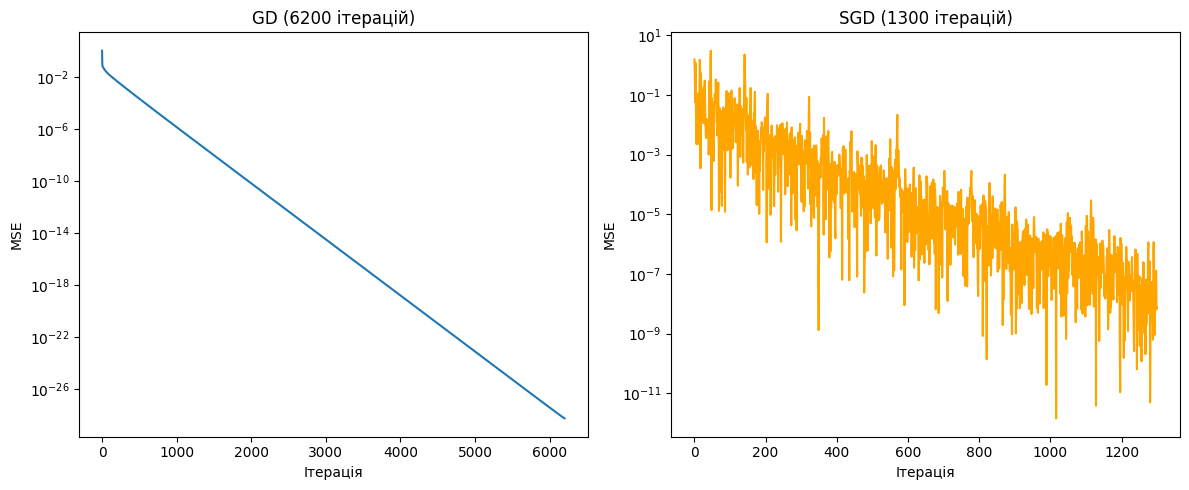

In [19]:
np.random.seed(42)
w_gd, losses_gd = gradient_descent(X_scaled, y_scaled, lr=0.1, n_iter=6200)

np.random.seed(42)
w_sgd, losses_sgd = gradient_descent_SGD(X_scaled, y_scaled, lr=0.1, n_iter=1300)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(losses_gd)
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('GD (6200 ітерацій)')
plt.yscale('log')

plt.subplot(1,2,2)
plt.plot(losses_sgd, color='orange')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('SGD (1300 ітерацій)')
plt.yscale('log')

plt.tight_layout()
plt.show()

SGD: крива навчання шумна (через 1 приклад на ітерацію)
     але швидше досягає мінімуму
GD: крива гладка, стабільна, але повільніша

RMSProp

In [20]:
def gradient_descent_RMSProp(X, y, lr, n_iter, beta=0.9, eps=1e-8):
    n, m = X.shape
    w = np.zeros(m)
    s = np.zeros(m)
    losses = []

    for i in range(n_iter):
        y_pred = X @ w
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)

        gradient = (2/n) * X.T @ (y_pred - y)

        s = beta * s + (1 - beta) * gradient ** 2
        w = w - lr * gradient / (np.sqrt(s) + eps)

    return w, losses

In [21]:
for n_iter_test in [500, 1000, 1500, 2000, 3000, 5000]:
    w_test, losses_test = gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.1, n_iter=n_iter_test)
    y_pred_test = X_scaled @ w_test
    true_loss = np.mean((y_scaled - y_pred_test) ** 2)
    print(f"n_iter={n_iter_test}: справжня помилка = {true_loss:.8f}, w={w_test}")

n_iter=500: справжня помилка = 0.03398603, w=[ 0.          0.5216203  -0.87924161  0.68177515 -0.17459281  0.85761721]
n_iter=1000: справжня помилка = 0.03398603, w=[ 0.          0.52158627 -0.87929184  0.68180395 -0.17458445  0.85766218]
n_iter=1500: справжня помилка = 0.03398603, w=[ 0.          0.52158627 -0.87929184  0.68180396 -0.17458445  0.85766218]
n_iter=2000: справжня помилка = 0.03398603, w=[ 0.          0.52158627 -0.87929184  0.68180396 -0.17458445  0.85766218]
n_iter=3000: справжня помилка = 0.03398603, w=[ 0.          0.52158627 -0.87929184  0.68180396 -0.17458445  0.85766218]
n_iter=5000: справжня помилка = 0.03398603, w=[ 0.          0.52158627 -0.87929184  0.68180396 -0.17458445  0.85766218]


In [22]:
w_test, losses_test = gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.01, n_iter=1000)
y_pred_test = X_scaled @ w_test
true_loss = np.mean((y_scaled - y_pred_test) ** 2)
print(f"lr=0.01: справжня помилка = {true_loss:.8f}")

lr=0.01: справжня помилка = 0.00033986


In [23]:
w_test, losses_test = gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.0001, n_iter=6000)
y_pred_test = X_scaled @ w_test
true_loss = np.mean((y_scaled - y_pred_test) ** 2)
print(f"lr0.0001: справжня помилка = {true_loss:.8f}")

lr0.0001: справжня помилка = 0.02625495


In [24]:
w_test, losses_test = gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.001, n_iter=5000)
y_pred_test = X_scaled @ w_test
true_loss = np.mean((y_scaled - y_pred_test) ** 2)
print(f"lr=0.01: справжня помилка = {true_loss:.8f}")

lr=0.01: справжня помилка = 0.00000340


In [25]:
for n_iter_test in [1000, 2000, 3000, 4000, 5000]:
    w_test, losses_test = gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.001, n_iter=n_iter_test)
    y_pred_test = X_scaled @ w_test
    true_loss = np.mean((y_scaled - y_pred_test) ** 2)
    print(f"n_iter={n_iter_test}: справжня помилка = {true_loss:.8f}")

n_iter=1000: справжня помилка = 0.00264853
n_iter=2000: справжня помилка = 0.00000340
n_iter=3000: справжня помилка = 0.00000340
n_iter=4000: справжня помилка = 0.00000340
n_iter=5000: справжня помилка = 0.00000340


In [26]:
%timeit gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.001, n_iter=2000)

47.8 ms ± 12.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


RMSProp: оптимальна кількість ітерацій ≈ 2000
         з lr=0.001 (менший ніж у GD/SGD!)
         фінальна помилка ≈ 0.0000034

GD:      147 ms ± 19 ms    (6200 ітерацій)
SGD:     16.2 ms ± 2.99 ms (1300 ітерацій)
RMSProp: 54.6 ms ± 8.66 ms (2000 ітерацій)

Adam

In [28]:
def gradient_descent_Adam(X, y, lr, n_iter, beta1=0.9, beta2=0.999, eps=1e-8):
    n, m = X.shape
    w = np.zeros(m)
    m_adam = np.zeros(m)
    s_adam = np.zeros(m)
    losses = []

    for i in range(n_iter):
        t = i + 1
        y_pred = X @ w
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)

        gradient = (2/n) * X.T @ (y_pred - y)

        m_adam = beta1 * m_adam + (1 - beta1) * gradient
        s_adam = beta2 * s_adam + (1 - beta2) * gradient ** 2

        m_corr = m_adam / (1 - beta1 ** t)
        s_corr = s_adam / (1 - beta2 ** t)

        w = w - lr * m_corr / (np.sqrt(s_corr) + eps)

    return w, losses

In [29]:
w_adam, losses_adam = gradient_descent_Adam(X_scaled, y_scaled, lr=0.1, n_iter=1000)
y_pred_adam = X_scaled @ w_adam
true_loss = np.mean((y_scaled - y_pred_adam) ** 2)
print(f"Справжня помилка Adam: {true_loss:.8f}")

Справжня помилка Adam: 0.00000000


In [30]:
for n_iter_test in [100, 300, 500, 700, 1000]:
    w_test, losses_test = gradient_descent_Adam(X_scaled, y_scaled, lr=0.1, n_iter=n_iter_test)
    y_pred_test = X_scaled @ w_test
    true_loss = np.mean((y_scaled - y_pred_test) ** 2)
    print(f"n_iter={n_iter_test}: справжня помилка = {true_loss:.8f}")

n_iter=100: справжня помилка = 0.00003724
n_iter=300: справжня помилка = 0.00000000
n_iter=500: справжня помилка = 0.00000000
n_iter=700: справжня помилка = 0.00000000
n_iter=1000: справжня помилка = 0.00000000


In [31]:
%timeit gradient_descent_Adam(X_scaled, y_scaled, lr=0.1, n_iter=300)

8.43 ms ± 1.49 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


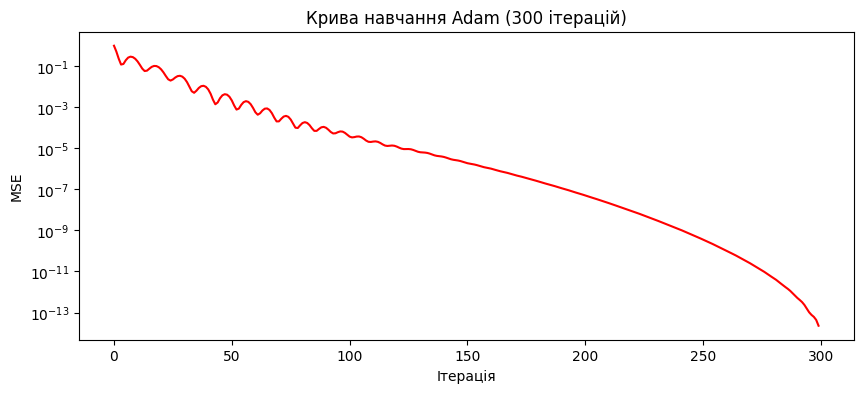

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(losses_adam, color='red')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Крива навчання Adam (300 ітерацій)')
plt.yscale('log')
plt.show()

In [38]:
def gradient_descent_Nadam(X, y, lr, n_iter, beta1=0.9, beta2=0.999, eps=1e-8):
    n, m = X.shape
    w = np.zeros(m)
    m_adam = np.zeros(m)
    s_adam = np.zeros(m)
    losses = []

    for i in range(n_iter):
        t = i + 1
        y_pred = X @ w
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)

        gradient = (2/n) * X.T @ (y_pred - y)

        m_adam = beta1 * m_adam + (1 - beta1) * gradient
        s_adam = beta2 * s_adam + (1 - beta2) * gradient ** 2

        m_corr = m_adam / (1 - beta1 ** t)
        s_corr = s_adam / (1 - beta2 ** t)

        w = w - lr * (beta1 * m_corr + (1-beta1) * gradient / (1 - beta1**t)) / (np.sqrt(s_corr) + eps)

    return w, losses



In [39]:
w_nadam, losses_nadam = gradient_descent_Nadam(X_scaled, y_scaled, lr=0.1, n_iter=300)
y_pred_nadam = X_scaled @ w_nadam
true_loss = np.mean((y_scaled - y_pred_nadam) ** 2)
print(f"Справжня помилка Nadam: {true_loss:.8f}")

Справжня помилка Nadam: 0.00000000


In [40]:
def find_optimal_iterations(func, X, y, lr, threshold=1e-6, step=50, max_iter=10000):
    for n_iter in range(step, max_iter, step):
        w, losses = func(X, y, lr=lr, n_iter=n_iter)
        y_pred = X @ w
        true_loss = np.mean((y - y_pred) ** 2)
        if true_loss < threshold:
            print(f"Оптимальна кількість ітерацій: {n_iter}, помилка: {true_loss:.8f}")
            return n_iter
    print("Не знайдено!")
    return max_iter

In [41]:
find_optimal_iterations(gradient_descent_Nadam, X_scaled, y_scaled, lr=0.1)

Оптимальна кількість ітерацій: 150, помилка: 0.00000006


150

In [42]:
%timeit gradient_descent_Nadam(X_scaled, y_scaled, lr=0.1, n_iter=150)

4.73 ms ± 1.2 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


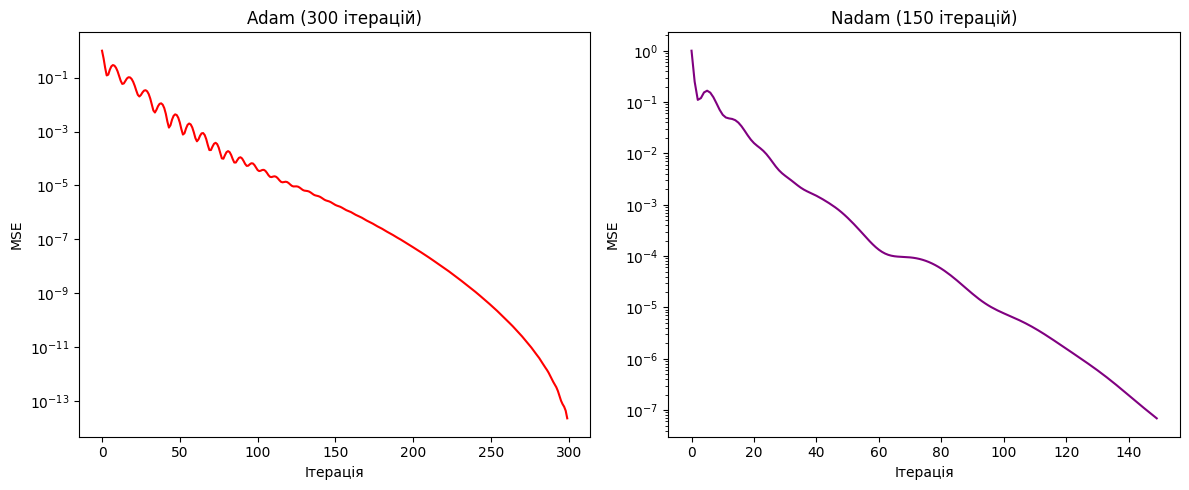

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_adam, color='red')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Adam (300 ітерацій)')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(losses_nadam, color='purple')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Nadam (150 ітерацій)')
plt.yscale('log')

plt.tight_layout()
plt.show()

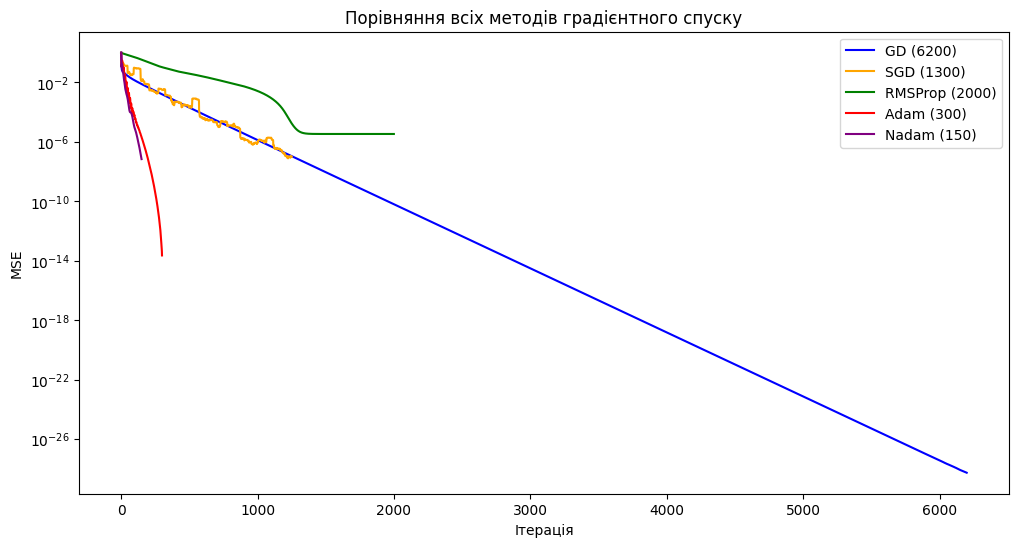

In [43]:

w_gd, losses_gd = gradient_descent(X_scaled, y_scaled, lr=0.1, n_iter=6200)
np.random.seed(42)
w_sgd, losses_sgd = gradient_descent_SGD(X_scaled, y_scaled, lr=0.1, n_iter=1300)
w_rms, losses_rms = gradient_descent_RMSProp(X_scaled, y_scaled, lr=0.001, n_iter=2000)
w_adam, losses_adam = gradient_descent_Adam(X_scaled, y_scaled, lr=0.1, n_iter=300)
w_nadam, losses_nadam = gradient_descent_Nadam(X_scaled, y_scaled, lr=0.1, n_iter=150)

# Графік
plt.figure(figsize=(12, 6))
plt.plot(losses_gd, label='GD (6200)', color='blue')
plt.plot(smooth(losses_sgd), label='SGD (1300)', color='orange')
plt.plot(losses_rms, label='RMSProp (2000)', color='green')
plt.plot(losses_adam, label='Adam (300)', color='red')
plt.plot(losses_nadam, label='Nadam (150)', color='purple')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.title('Порівняння всіх методів градієнтного спуску')
plt.yscale('log')
plt.legend()
plt.show()


 Фінальні висновки

 Підготовка даних (критично важливо!):
- Нормалізувати і X (StandardScaler) і y (вручну)
- Без нормалізації y — помилка застряє на 0.74

 Порівняння методів:
| Метод   | Час      | Ітерації | Крива         |
|---------|----------|----------|---------------|
| GD      | 147 ms   | 6200     | гладка        |
| SGD     | 16.2 ms  | 1300     | шумна         |
| RMSProp | 54.6 ms  | 2000     | гладка        |
| Adam    | 8.43 ms  | 300      | гладка        |
| Nadam   | 4.73 ms  | 150      | найплавніша   |

 Висновок:
Nadam — найефективніший метод:
- вдвічі швидший за Adam
- плавніша крива завдяки погляду "вперед"
- рекомендований для практичного використання